In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Load the .npz file
data = np.load('PneumoniaMNIST/pneumoniamnist.npz')

# The keys are: 'train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels'
train_images = data['train_images']  # shape: (num_train, 28, 28)
train_labels = data['train_labels']  # shape: (num_train,)
val_images = data['val_images']
val_labels = data['val_labels']
test_images = data['test_images']
test_labels = data['test_labels']

print(f"Train shape: {train_images.shape}, labels: {train_labels.shape}")
print(f"Val shape: {val_images.shape}, labels: {val_labels.shape}")
print(f"Test shape: {test_images.shape}, labels: {test_labels.shape}")

Train shape: (3882, 28, 28), labels: (3882, 1)
Val shape: (524, 28, 28), labels: (524, 1)
Test shape: (624, 28, 28), labels: (624, 1)


In [3]:
class PneumoniaMNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)  # (28,28)
        # Add channel dimension: (28,28) -> (1,28,28)
        img = np.expand_dims(img, axis=0)
        # Convert to tensor
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [4]:
# Optional: add a transform to normalize to [0,1] (already 0-255? Actually pixel values are 0-255? Let's check)
# The images are likely uint8 (0-255). We'll scale to [0,1] by dividing by 255.
transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0)  # scale to [0,1]
])

train_dataset = PneumoniaMNISTDataset(train_images, train_labels, transform=transform)
val_dataset = PneumoniaMNISTDataset(val_images, val_labels, transform=transform)
test_dataset = PneumoniaMNISTDataset(test_images, test_labels, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
for images, labels in train_loader:
    print(images.shape, labels.shape)  # e.g., torch.Size([64, 1, 28, 28]) torch.Size([64])
    break

torch.Size([64, 1, 28, 28]) torch.Size([64, 1])


In [7]:
import torch
import torch.nn as nn
from performer_pytorch import Performer

class LinearAttentionViT(nn.Module):
    def __init__(self, image_size=28, patch_size=4, num_classes=2, dim=128, depth=4, heads=4):
        super().__init__()
        # Patch embedding
        self.patch_embed = nn.Conv2d(1, dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (image_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, dim) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        # Transformer blocks with Performer (linear attention)
        self.blocks = nn.ModuleList([])
        for _ in range(depth):
            self.blocks.append(nn.ModuleList([
                nn.LayerNorm(dim),
                Performer(dim=dim, heads=heads, causal=False, feature_redraw_interval=1000),
                nn.LayerNorm(dim),
                nn.Sequential(
                    nn.Linear(dim, dim*4),
                    nn.GELU(),
                    nn.Linear(dim*4, dim)
                )
            ]))
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        # Patch embedding: (B,1,H,W) -> (B,dim, H',W') -> (B, num_patches, dim)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        # Class token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        # Add positional embedding
        x = x + self.pos_embed
        # Transformer blocks
        for ln1, attn, ln2, mlp in self.blocks:
            x = x + attn(ln1(x))
            x = x + mlp(ln2(x))
        x = self.norm(x)
        return self.head(x[:, 0])  # class token output

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import time
from performer_pytorch import Performer

# ------------------------------
# 1. Data Loading
# ------------------------------
# Load the .npz file
data = np.load('PneumoniaMNIST/pneumoniamnist.npz')

train_images = data['train_images']  # shape (num_train, 28, 28)
train_labels = data['train_labels']  # shape (num_train, 1)
val_images   = data['val_images']
val_labels   = data['val_labels']
test_images  = data['test_images']
test_labels  = data['test_labels']

print(f"Train: {train_images.shape}, labels: {train_labels.shape}")
print(f"Val:   {val_images.shape},   labels: {val_labels.shape}")
print(f"Test:  {test_images.shape},  labels: {test_labels.shape}")

# Dataset class (with label squeezing)
class PneumoniaMNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)          # (28,28)
        img = np.expand_dims(img, axis=0)                  # (1,28,28)
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        # Ensure label is a scalar tensor (not a 1‑element tensor)
        label = torch.tensor(self.labels[idx], dtype=torch.long).squeeze()
        return img, label

# Transform: scale to [0,1]
transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0)
])

train_dataset = PneumoniaMNISTDataset(train_images, train_labels, transform=transform)
val_dataset   = PneumoniaMNISTDataset(val_images, val_labels,   transform=transform)
test_dataset  = PneumoniaMNISTDataset(test_images, test_labels, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Verify a batch
for images, labels in train_loader:
    print(images.shape, labels.shape)  # e.g., torch.Size([64, 1, 28, 28]) torch.Size([64])
    break

# ------------------------------
# 2. Model Definition (ViT with Performer linear attention)
# ------------------------------
class LinearAttentionViT(nn.Module):
    def __init__(self, image_size=28, patch_size=4, num_classes=2, dim=128, depth=4, heads=4):
        super().__init__()
        # Patch embedding: (B,1,H,W) -> (B,dim, H/patch, W/patch)
        self.patch_embed = nn.Conv2d(1, dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (image_size // patch_size) ** 2
        # Positional embedding for patches + class token (now includes class token position)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        # Transformer blocks with Performer (linear attention)
        self.blocks = nn.ModuleList([])
        for _ in range(depth):
            self.blocks.append(nn.ModuleList([
                nn.LayerNorm(dim),
                Performer(dim=dim, depth=1, heads=heads, dim_head=dim//heads, causal=False, feature_redraw_interval=1000),
                nn.LayerNorm(dim),
                nn.Sequential(
                    nn.Linear(dim, dim*4),
                    nn.GELU(),
                    nn.Linear(dim*4, dim)
                )
            ]))
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        # Patch embedding: (B,1,H,W) -> (B, dim, H', W') -> (B, num_patches, dim)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)  # (B, num_patches, dim)
        # Class token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)              # (B, num_patches+1, dim)
        # Add positional embeddings
        x = x + self.pos_embed
        # Transformer blocks
        for ln1, attn, ln2, mlp in self.blocks:
            x = x + attn(ln1(x))
            x = x + mlp(ln2(x))
        x = self.norm(x)
        # Classification head (using class token)
        return self.head(x[:, 0])

# ------------------------------
# 3. Training Setup
# ------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LinearAttentionViT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

epochs = 10
train_losses = []
val_accs = []
epoch_times = []

for epoch in range(epochs):
    start_time = time.time()

    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)  # labels are now 1D due to squeeze
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation phase
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total
    val_accs.append(val_acc)

    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}% | Time: {epoch_time:.2f}s")

# ------------------------------
# 4. Test Evaluation
# ------------------------------
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_acc = 100 * correct / total
print(f"\nTest Accuracy: {test_acc:.2f}%")

# ------------------------------
# 5. Efficiency Metrics
# ------------------------------
print("\n--- Efficiency Metrics ---")
print(f"Average training time per epoch: {sum(epoch_times)/len(epoch_times):.2f}s")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
else:
    print("Running on CPU (no GPU metrics)")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Train: (3882, 28, 28), labels: (3882, 1)
Val:   (524, 28, 28),   labels: (524, 1)
Test:  (624, 28, 28),  labels: (624, 1)
torch.Size([64, 1, 28, 28]) torch.Size([64])
Epoch 1/10 | Loss: 0.3498 | Val Acc: 74.24% | Time: 5.86s
Epoch 2/10 | Loss: 0.3121 | Val Acc: 74.24% | Time: 5.37s
Epoch 3/10 | Loss: 0.2672 | Val Acc: 76.91% | Time: 5.41s
Epoch 4/10 | Loss: 0.2172 | Val Acc: 83.02% | Time: 5.56s
Epoch 5/10 | Loss: 0.1548 | Val Acc: 83.78% | Time: 5.75s
Epoch 6/10 | Loss: 0.1096 | Val Acc: 94.47% | Time: 5.59s
Epoch 7/10 | Loss: 0.1011 | Val Acc: 94.08% | Time: 5.82s
Epoch 8/10 | Loss: 0.0911 | Val Acc: 94.47% | Time: 6.55s
Epoch 9/10 | Loss: 0.0854 | Val Acc: 94.27% | Time: 6.42s
Epoch 10/10 | Loss: 0.0837 | Val Acc: 95.04% | Time: 6.48s

Test Accuracy: 78.21%

--- Efficiency Metrics ---
Average training time per epoch: 5.88s
GPU memory allocated: 337.47 MB
Total parameters: 1,331,202


In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import time
from performer_pytorch import Performer

# ------------------------------
# 1. Data Loading
# ------------------------------
data = np.load('PneumoniaMNIST/pneumoniamnist.npz')
train_images = data['train_images']
train_labels = data['train_labels']
val_images   = data['val_images']
val_labels   = data['val_labels']
test_images  = data['test_images']
test_labels  = data['test_labels']

print(f"Train: {train_images.shape}, labels: {train_labels.shape}")
print(f"Val:   {val_images.shape},   labels: {val_labels.shape}")
print(f"Test:  {test_images.shape},  labels: {test_labels.shape}")

# Dataset class
class PneumoniaMNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)
        img = np.expand_dims(img, axis=0)
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long).squeeze()
        return img, label

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])

# For validation and test: only scaling
val_transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0)
])

train_dataset = PneumoniaMNISTDataset(train_images, train_labels, transform=train_transform)
val_dataset   = PneumoniaMNISTDataset(val_images, val_labels,   transform=val_transform)
test_dataset  = PneumoniaMNISTDataset(test_images, test_labels, transform=val_transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# ------------------------------
# 2. Model Definition (with Dropout)
# ------------------------------
class LinearAttentionViT(nn.Module):
    def __init__(self, image_size=28, patch_size=4, num_classes=2, dim=128, depth=4, heads=4, dropout=0.2):
        super().__init__()
        self.patch_embed = nn.Conv2d(1, dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (image_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        self.blocks = nn.ModuleList([])
        for _ in range(depth):
            self.blocks.append(nn.ModuleList([
                nn.LayerNorm(dim),
                Performer(dim=dim, depth=1, heads=heads, dim_head=dim//heads, causal=False, feature_redraw_interval=1000),
                nn.LayerNorm(dim),
                nn.Sequential(
                    nn.Linear(dim, dim*4),
                    nn.GELU(),
                    nn.Dropout(dropout),          # dropout after activation
                    nn.Linear(dim*4, dim),
                    nn.Dropout(dropout)           # dropout after projection
                )
            ]))
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        for ln1, attn, ln2, mlp in self.blocks:
            x = x + attn(ln1(x))
            x = x + mlp(ln2(x))
        x = self.norm(x)
        return self.head(x[:, 0])

# ------------------------------
# 3. Training with Early Stopping
# ------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LinearAttentionViT(dropout=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 30
best_val_loss = float('inf')
patience = 5
counter = 0
best_model_state = None

train_losses = []
val_losses = []
val_accs = []
epoch_times = []

for epoch in range(epochs):
    start_time = time.time()

    # Training
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct / total
    val_accs.append(val_acc)

    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | Time: {epoch_time:.2f}s")

    # Early stopping based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(best_model_state)

# ------------------------------
# 4. Test Evaluation
# ------------------------------
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_acc = 100 * correct / total
print(f"\nTest Accuracy: {test_acc:.2f}%")

# ------------------------------
# 5. Efficiency Metrics
# ------------------------------
print("\n--- Efficiency Metrics ---")
print(f"Average training time per epoch: {sum(epoch_times)/len(epoch_times):.2f}s")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Train: (3882, 28, 28), labels: (3882, 1)
Val:   (524, 28, 28),   labels: (524, 1)
Test:  (624, 28, 28),  labels: (624, 1)
Epoch 1/30 | Train Loss: 0.3588 | Val Loss: 0.6908 | Val Acc: 74.24% | Time: 9.24s
Epoch 2/30 | Train Loss: 0.3246 | Val Loss: 0.6532 | Val Acc: 74.24% | Time: 8.79s
Epoch 3/30 | Train Loss: 0.3232 | Val Loss: 0.6510 | Val Acc: 74.24% | Time: 10.14s
Epoch 4/30 | Train Loss: 0.3214 | Val Loss: 0.6881 | Val Acc: 74.24% | Time: 10.43s
Epoch 5/30 | Train Loss: 0.3186 | Val Loss: 0.6665 | Val Acc: 74.24% | Time: 12.84s
Epoch 6/30 | Train Loss: 0.3134 | Val Loss: 0.6757 | Val Acc: 74.24% | Time: 12.89s
Epoch 7/30 | Train Loss: 0.2749 | Val Loss: 0.3771 | Val Acc: 79.96% | Time: 12.48s
Epoch 8/30 | Train Loss: 0.2248 | Val Loss: 0.3501 | Val Acc: 83.59% | Time: 12.85s
Epoch 9/30 | Train Loss: 0.1907 | Val Loss: 0.3206 | Val Acc: 85.11% | Time: 13.40s
Epoch 10/30 | Train Loss: 0.1762 | Val Loss: 0.4485 | Val Acc: 81.49% | Time: 13.25s
Epoch 11/30 | Train Loss: 0.1682 | Val 

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import time
from performer_pytorch import Performer
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

# ------------------------------
# 1. Data Loading with Strong Augmentation
# ------------------------------
data = np.load('PneumoniaMNIST/pneumoniamnist.npz')
train_images = data['train_images']
train_labels = data['train_labels']
val_images   = data['val_images']
val_labels   = data['val_labels']
test_images  = data['test_images']
test_labels  = data['test_labels']

print(f"Train: {train_images.shape}, labels: {train_labels.shape}")
print(f"Val:   {val_images.shape},   labels: {val_labels.shape}")
print(f"Test:  {test_images.shape},  labels: {test_labels.shape}")

class PneumoniaMNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)
        img = np.expand_dims(img, axis=0)  # (1,28,28)
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long).squeeze()
        return img, label

# Stronger augmentation for training
train_transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0)
])

train_dataset = PneumoniaMNISTDataset(train_images, train_labels, transform=train_transform)
val_dataset   = PneumoniaMNISTDataset(val_images, val_labels,   transform=val_transform)
test_dataset  = PneumoniaMNISTDataset(test_images, test_labels, transform=val_transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

# ------------------------------
# 2. Model with Reduced Capacity
# ------------------------------
class LinearAttentionViT(nn.Module):
    def __init__(self, image_size=28, patch_size=4, num_classes=2, dim=64, depth=2, heads=4, dropout=0.5):
        super().__init__()
        self.patch_embed = nn.Conv2d(1, dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (image_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        self.blocks = nn.ModuleList([])
        for _ in range(depth):
            self.blocks.append(nn.ModuleList([
                nn.LayerNorm(dim),
                Performer(dim=dim, depth=1, heads=heads, dim_head=dim//heads, causal=False, feature_redraw_interval=1000),
                nn.LayerNorm(dim),
                nn.Sequential(
                    nn.Linear(dim, dim*4),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(dim*4, dim),
                    nn.Dropout(dropout)
                )
            ]))
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        for ln1, attn, ln2, mlp in self.blocks:
            x = x + attn(ln1(x))
            x = x + mlp(ln2(x))
        x = self.norm(x)
        return self.head(x[:, 0])

# ------------------------------
# 3. Label Smoothing Loss
# ------------------------------
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_classes = pred.size(1)
        # one-hot encoding with smoothing
        one_hot = torch.zeros_like(pred).scatter(1, target.unsqueeze(1), 1)
        smooth_one_hot = one_hot * (1 - self.smoothing) + self.smoothing / n_classes
        log_prob = F.log_softmax(pred, dim=1)
        loss = -(smooth_one_hot * log_prob).sum(dim=1).mean()
        return loss

# ------------------------------
# 4. Training with Scheduler and Early Stopping
# ------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LinearAttentionViT(dim=64, depth=2, heads=4, dropout=0.5).to(device)
criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

epochs = 50
best_val_acc = 0.0
patience = 7
counter = 0
best_model_state = None

train_losses = []
val_accs = []
epoch_times = []

for epoch in range(epochs):
    start_time = time.time()

    # Training
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total
    val_accs.append(val_acc)

    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f} | Time: {epoch_time:.2f}s")

    # Early stopping based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    scheduler.step()

# Load best model
model.load_state_dict(best_model_state)

# ------------------------------
# 5. Test Evaluation
# ------------------------------
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_acc = 100 * correct / total
print(f"\nTest Accuracy: {test_acc:.2f}%")

# ------------------------------
# 6. Efficiency Metrics
# ------------------------------
print("\n--- Efficiency Metrics ---")
print(f"Average training time per epoch: {sum(epoch_times)/len(epoch_times):.2f}s")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Train: (3882, 28, 28), labels: (3882, 1)
Val:   (524, 28, 28),   labels: (524, 1)
Test:  (624, 28, 28),  labels: (624, 1)
Epoch 1/50 | Train Loss: 0.4180 | Val Acc: 74.24% | LR: 0.001000 | Time: 5.43s
Epoch 2/50 | Train Loss: 0.4064 | Val Acc: 74.24% | LR: 0.000997 | Time: 5.07s
Epoch 3/50 | Train Loss: 0.4027 | Val Acc: 74.24% | LR: 0.000989 | Time: 5.26s
Epoch 4/50 | Train Loss: 0.3591 | Val Acc: 74.24% | LR: 0.000976 | Time: 5.30s
Epoch 5/50 | Train Loss: 0.3407 | Val Acc: 79.39% | LR: 0.000957 | Time: 6.22s
Epoch 6/50 | Train Loss: 0.3428 | Val Acc: 78.63% | LR: 0.000934 | Time: 6.15s
Epoch 7/50 | Train Loss: 0.3267 | Val Acc: 81.68% | LR: 0.000905 | Time: 6.30s
Epoch 8/50 | Train Loss: 0.3218 | Val Acc: 82.25% | LR: 0.000873 | Time: 6.60s
Epoch 9/50 | Train Loss: 0.3206 | Val Acc: 78.63% | LR: 0.000836 | Time: 6.50s
Epoch 10/50 | Train Loss: 0.3153 | Val Acc: 77.29% | LR: 0.000796 | Time: 6.62s
Epoch 11/50 | Train Loss: 0.3234 | Val Acc: 83.21% | LR: 0.000753 | Time: 7.58s
Epoch 1

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import time

# ------------------------------
# 1. Data Loading (same as before)
# ------------------------------
data = np.load('PneumoniaMNIST/pneumoniamnist.npz')
train_images = data['train_images']
train_labels = data['train_labels']
val_images   = data['val_images']
val_labels   = data['val_labels']
test_images  = data['test_images']
test_labels  = data['test_labels']

print(f"Train: {train_images.shape}, labels: {train_labels.shape}")
print(f"Val:   {val_images.shape},   labels: {val_labels.shape}")
print(f"Test:  {test_images.shape},  labels: {test_labels.shape}")

class PneumoniaMNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)
        img = np.expand_dims(img, axis=0)  # (1,28,28)
        # ResNet expects 3‑channel input, so repeat the channel 3 times
        img = np.repeat(img, 3, axis=0)    # (3,28,28)
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long).squeeze()
        return img, label

# Stronger augmentation for training (resize to 224x224 for ResNet)
train_transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = PneumoniaMNISTDataset(train_images, train_labels, transform=train_transform)
val_dataset   = PneumoniaMNISTDataset(val_images, val_labels,   transform=val_transform)
test_dataset  = PneumoniaMNISTDataset(test_images, test_labels, transform=val_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

# ------------------------------
# 2. Load Pre‑trained ResNet‑18
# ------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(pretrained=True)

# Freeze early layers (optional)
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier head for 2 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# Unfreeze the last few layers for fine‑tuning (optional)
# Here we unfreeze all layers for full fine‑tuning (better accuracy)
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

# ------------------------------
# 3. Training Setup
# ------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

epochs = 20
best_val_acc = 0.0
best_model_state = None

for epoch in range(epochs):
    start_time = time.time()

    # Training
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f} | Time: {epoch_time:.2f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()

    scheduler.step()

# Load best model
model.load_state_dict(best_model_state)

# ------------------------------
# 4. Test Evaluation
# ------------------------------
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_acc = 100 * correct / total
print(f"\nTest Accuracy: {test_acc:.2f}%")

Train: (3882, 28, 28), labels: (3882, 1)
Val:   (524, 28, 28),   labels: (524, 1)
Test:  (624, 28, 28),  labels: (624, 1)


c:\Users\SUBHADEEP SASMAL\Desktop\ITAD Journal\TSD ( KSD ) to GRAPH NODES\myenv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\SUBHADEEP SASMAL\Desktop\ITAD Journal\TSD ( KSD ) to GRAPH NODES\myenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 | Train Loss: 0.1404 | Val Acc: 92.56% | LR: 0.000100 | Time: 138.07s
Epoch 2/20 | Train Loss: 0.0799 | Val Acc: 95.23% | LR: 0.000099 | Time: 136.25s
Epoch 3/20 | Train Loss: 0.0575 | Val Acc: 96.95% | LR: 0.000098 | Time: 172.82s
Epoch 4/20 | Train Loss: 0.0470 | Val Acc: 91.22% | LR: 0.000095 | Time: 144.00s
Epoch 5/20 | Train Loss: 0.0404 | Val Acc: 96.18% | LR: 0.000091 | Time: 143.94s
Epoch 6/20 | Train Loss: 0.0379 | Val Acc: 96.76% | LR: 0.000086 | Time: 185.43s
Epoch 7/20 | Train Loss: 0.0356 | Val Acc: 96.95% | LR: 0.000080 | Time: 127.48s
Epoch 8/20 | Train Loss: 0.0239 | Val Acc: 97.33% | LR: 0.000073 | Time: 70.60s
Epoch 9/20 | Train Loss: 0.0235 | Val Acc: 96.56% | LR: 0.000066 | Time: 70.41s
Epoch 10/20 | Train Loss: 0.0163 | Val Acc: 94.47% | LR: 0.000058 | Time: 77.08s
Epoch 11/20 | Train Loss: 0.0129 | Val Acc: 96.95% | LR: 0.000051 | Time: 70.82s
Epoch 12/20 | Train Loss: 0.0092 | Val Acc: 96.76% | LR: 0.000043 | Time: 75.84s
Epoch 13/20 | Train Loss: 0.01

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import random

# ------------------------------
# 1. Data Loading with Mixed Augmentation
# ------------------------------
data = np.load('PneumoniaMNIST/pneumoniamnist.npz')
train_images = data['train_images']
train_labels = data['train_labels']
val_images   = data['val_images']
val_labels   = data['val_labels']
test_images  = data['test_images']
test_labels  = data['test_labels']

print(f"Train: {train_images.shape}, labels: {train_labels.shape}")
print(f"Val:   {val_images.shape},   labels: {val_labels.shape}")
print(f"Test:  {test_images.shape},  labels: {test_labels.shape}")

class PneumoniaMNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)
        img = np.expand_dims(img, axis=0)
        img = np.repeat(img, 3, axis=0)   # 3 channels
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long).squeeze()
        return img, label

# Strong augmentation for training
train_transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = PneumoniaMNISTDataset(train_images, train_labels, transform=train_transform)
val_dataset   = PneumoniaMNISTDataset(val_images, val_labels,   transform=val_transform)
test_dataset  = PneumoniaMNISTDataset(test_images, test_labels, transform=val_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

# ------------------------------
# 2. Model: ResNet‑50 with Pre‑trained Weights
# ------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(pretrained=True)
# Replace classifier
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

# ------------------------------
# 3. MixUp Helper Function
# ------------------------------
def mixup_data(x, y, alpha=0.2):
    """Returns mixed inputs, pairs of targets, and lambda"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ------------------------------
# 4. Label Smoothing Criterion
# ------------------------------
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_classes = pred.size(1)
        one_hot = torch.zeros_like(pred).scatter(1, target.unsqueeze(1), 1)
        smooth_one_hot = one_hot * (1 - self.smoothing) + self.smoothing / n_classes
        log_prob = torch.log_softmax(pred, dim=1)
        loss = -(smooth_one_hot * log_prob).sum(dim=1).mean()
        return loss

# ------------------------------
# 5. Training Setup with Cosine Annealing & Early Stopping
# ------------------------------
criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

epochs = 30
best_val_acc = 0.0
patience = 7
counter = 0
best_model_state = None

train_losses = []
val_losses = []
val_accs = []

for epoch in range(epochs):
    start_time = time.time()

    # Training with MixUp
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Apply MixUp with probability 0.5
        if random.random() < 0.5:
            images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2)
            optimizer.zero_grad()
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        else:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct / total
    val_accs.append(val_acc)

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f} | Time: {epoch_time:.2f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    scheduler.step()

# Load best model
model.load_state_dict(best_model_state)

# ------------------------------
# 6. Test‑Time Augmentation (TTA)
# ------------------------------
def test_time_augmentation(model, loader, device, flip=True):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            # Original
            outputs = model(images)
            preds = torch.softmax(outputs, dim=1)
            if flip:
                # Horizontal flip
                flipped = torch.flip(images, dims=[3])
                outputs_flip = model(flipped)
                preds_flip = torch.softmax(outputs_flip, dim=1)
                preds = (preds + preds_flip) / 2
            _, predicted = torch.max(preds, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds) * 100

test_acc = test_time_augmentation(model, test_loader, device, flip=True)
print(f"\nTest Accuracy (with TTA): {test_acc:.2f}%")

# ------------------------------
# 7. Plotting (Times New Roman, 300 dpi)
# ------------------------------
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(val_accs, label='Val Accuracy', linewidth=2, color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------
# 8. Save model and results
# ------------------------------
torch.save(model.state_dict(), 'best_model.pth')
print("\nModel saved as best_model.pth")

Train: (3882, 28, 28), labels: (3882, 1)
Val:   (524, 28, 28),   labels: (524, 1)
Test:  (624, 28, 28),  labels: (624, 1)


c:\Users\SUBHADEEP SASMAL\Desktop\ITAD Journal\TSD ( KSD ) to GRAPH NODES\myenv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\SUBHADEEP SASMAL\Desktop\ITAD Journal\TSD ( KSD ) to GRAPH NODES\myenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


KeyboardInterrupt: 

Keys in file: ['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']
Train : (3882, 28, 28) | Labels: [0 1]
Val   : (524, 28, 28)
Test  : (624, 28, 28)
Train class balance — 0: 388 | 1: 3494


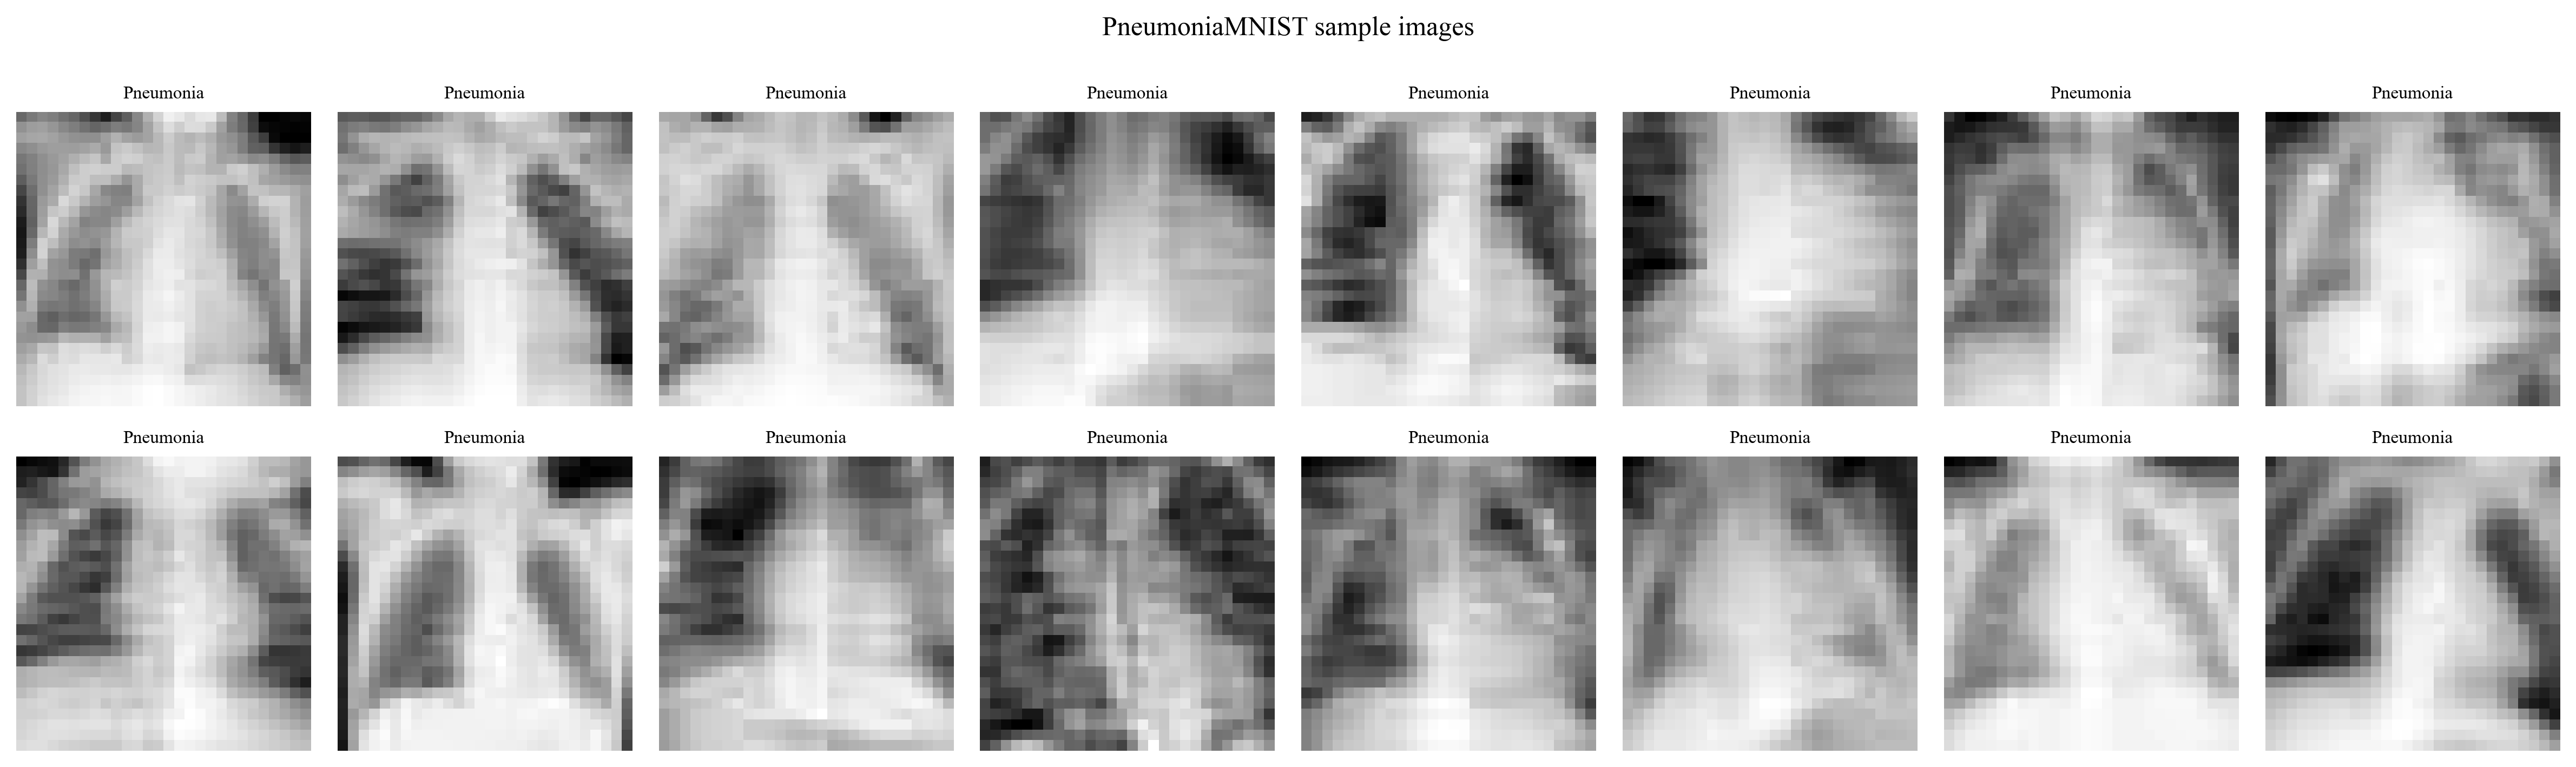

Saved sample_grid.png


In [1]:
import matplotlib
matplotlib.rcParams['font.family']      = 'Times New Roman'
matplotlib.rcParams['font.size']        = 11
matplotlib.rcParams['axes.titlesize']   = 12
matplotlib.rcParams['axes.labelsize']   = 11
matplotlib.rcParams['xtick.labelsize']  = 10
matplotlib.rcParams['ytick.labelsize']  = 10
matplotlib.rcParams['legend.fontsize']  = 9
matplotlib.rcParams['figure.dpi']       = 300


import numpy as np
import matplotlib.pyplot as plt

# Load directly from your .npz file
data = np.load('PneumoniaMNIST/pneumoniamnist.npz')

print("Keys in file:", list(data.keys()))

train_images = data['train_images']   # shape: (N, 28, 28)
train_labels = data['train_labels']   # shape: (N, 1)
val_images   = data['val_images']
val_labels   = data['val_labels']
test_images  = data['test_images']
test_labels  = data['test_labels']

print(f"Train : {train_images.shape} | Labels: {np.unique(train_labels)}")
print(f"Val   : {val_images.shape}")
print(f"Test  : {test_images.shape}")
print(f"Train class balance — 0: {(train_labels==0).sum()} | 1: {(train_labels==1).sum()}")

# Plot a small grid
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title("Pneumonia" if train_labels[i][0] == 1 else "Normal", fontsize=8)
    ax.axis('off')
plt.suptitle("PneumoniaMNIST sample images", fontsize=12)
plt.tight_layout()
plt.savefig('sample_grid.png', dpi=300)
plt.show()
print("Saved sample_grid.png")

In [5]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class PneumoniaDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        # images: (N, 28, 28) uint8
        # labels: (N, 1) int
        self.images    = images
        self.labels    = labels.squeeze().astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]          # (28, 28) uint8

        # Convert to PIL for transforms
        from PIL import Image
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


def get_loaders(npz_path='PneumoniaMNIST/pneumoniamnist.npz',
                batch_size=64, img_size=32):

    data = np.load(npz_path)

    transform_train = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    transform_eval = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    train_ds = PneumoniaDataset(data['train_images'], data['train_labels'], transform_train)
    val_ds   = PneumoniaDataset(data['val_images'],   data['val_labels'],   transform_eval)
    test_ds  = PneumoniaDataset(data['test_images'],  data['test_labels'],  transform_eval)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

    print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
    return train_loader, val_loader, test_loader


# Quick sanity check
if __name__ == '__main__':
    train_loader, val_loader, test_loader = get_loaders()
    imgs, labels = next(iter(train_loader))
    print(f"Batch shape: {imgs.shape} | Labels: {labels[:8]}")
    # Expected: torch.Size([64, 1, 32, 32])

Train batches: 61 | Val: 9 | Test: 10
Batch shape: torch.Size([64, 1, 32, 32]) | Labels: tensor([0, 1, 1, 1, 1, 1, 1, 1])


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange, repeat


def phi(x):
    return F.elu(x) + 1


class StandardAttention(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        self.heads    = heads
        self.head_dim = dim // heads
        self.scale    = self.head_dim ** -0.5
        self.qkv      = nn.Linear(dim, dim * 3, bias=False)
        self.proj     = nn.Linear(dim, dim)
        self.drop     = nn.Dropout(dropout)
        self.attn_weights = None

    def forward(self, x):
        B, N, _ = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.heads)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.heads)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.heads)

        attn = torch.einsum('bhid,bhjd->bhij', q, k) * self.scale
        attn = attn.softmax(dim=-1)
        self.attn_weights = attn.detach()
        attn = self.drop(attn)

        out = torch.einsum('bhij,bhjd->bhid', attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.proj(out)


class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        self.heads    = heads
        self.head_dim = dim // heads
        self.qkv      = nn.Linear(dim, dim * 3, bias=False)
        self.proj     = nn.Linear(dim, dim)
        self.drop     = nn.Dropout(dropout)
        self.attn_weights = None

    def forward(self, x):
        B, N, _ = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.heads)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.heads)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.heads)

        q, k = phi(q), phi(k)

        kv    = torch.einsum('bhnd,bhnm->bhdm', k, v)
        out   = torch.einsum('bhnd,bhdm->bhnm', q, kv)
        k_sum = k.sum(dim=2)
        denom = torch.einsum('bhnd,bhd->bhn', q, k_sum).unsqueeze(-1).clamp(min=1e-6)
        out   = out / denom

        with torch.no_grad():
            attn_approx = torch.einsum('bhnd,bhmd->bhnm', q, k)
            attn_approx = attn_approx / attn_approx.sum(dim=-1, keepdim=True).clamp(min=1e-6)
            self.attn_weights = attn_approx.detach()

        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.proj(out)


class Block(nn.Module):
    def __init__(self, dim, heads, mlp_dim, attn_cls, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = attn_cls(dim, heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class ViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, num_classes=2,
                 dim=128, depth=4, heads=4, mlp_dim=256,
                 attn_type='linear', dropout=0.1):
        super().__init__()

        assert image_size % patch_size == 0
        num_patches = (image_size // patch_size) ** 2
        patch_dim   = 1 * patch_size * patch_size

        self.patch_size  = patch_size
        self.num_patches = num_patches
        self.dim         = dim

        self.patch_embed = nn.Sequential(
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim) * 0.02)
        self.dropout   = nn.Dropout(dropout)

        attn_cls = LinearAttention if attn_type == 'linear' else StandardAttention

        self.blocks = nn.ModuleList([
            Block(dim, heads, mlp_dim, attn_cls, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(
            nn.Linear(dim, mlp_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim // 2, num_classes),
        )

    def forward(self, img):
        p = self.patch_size
        x = rearrange(img, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=p, p2=p)
        x = self.patch_embed(x)

        B = x.shape[0]
        cls = repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        x   = torch.cat([cls, x], dim=1) + self.pos_embed
        x   = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x[:, 0])
        return self.head(x)

    def get_attention_maps(self):
        return [block.attn.attn_weights for block in self.blocks]

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Sanity check
if __name__ == '__main__':
    for atype in ['standard', 'linear']:
        m = ViT(attn_type=atype)
        x = torch.randn(4, 1, 32, 32)
        y = m(x)
        print(f"{atype:10s} | output: {y.shape} | params: {m.count_parameters():,}")

standard   | output: torch.Size([4, 2]) | params: 556,322
linear     | output: torch.Size([4, 2]) | params: 556,322


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json, time, os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from einops import rearrange, repeat
from PIL import Image

# ── Dataset ─────────────────────────────────────────────────────────────

class PneumoniaDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels.squeeze().astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img   = Image.fromarray(self.images[idx])
        img   = self.transform(img) if self.transform else transforms.ToTensor()(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


def get_loaders(npz_path='PneumoniaMNIST/pneumoniamnist.npz', batch_size=64, img_size=32):
    data = np.load(npz_path)

    transform_train = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])
    transform_eval = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    train_ds = PneumoniaDataset(data['train_images'], data['train_labels'], transform_train)
    val_ds   = PneumoniaDataset(data['val_images'],   data['val_labels'],   transform_eval)
    test_ds  = PneumoniaDataset(data['test_images'],  data['test_labels'],  transform_eval)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader


# ── Model ────────────────────────────────────────────────────────────────

def phi(x):
    return F.elu(x) + 1

class StandardAttention(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        self.heads    = heads
        self.head_dim = dim // heads
        self.scale    = self.head_dim ** -0.5
        self.qkv      = nn.Linear(dim, dim * 3, bias=False)
        self.proj     = nn.Linear(dim, dim)
        self.drop     = nn.Dropout(dropout)
        self.attn_weights = None

    def forward(self, x):
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.heads)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.heads)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.heads)
        attn = (torch.einsum('bhid,bhjd->bhij', q, k) * self.scale).softmax(dim=-1)
        self.attn_weights = attn.detach()
        out  = torch.einsum('bhij,bhjd->bhid', self.drop(attn), v)
        return self.proj(rearrange(out, 'b h n d -> b n (h d)'))

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        self.heads    = heads
        self.head_dim = dim // heads
        self.qkv      = nn.Linear(dim, dim * 3, bias=False)
        self.proj     = nn.Linear(dim, dim)
        self.drop     = nn.Dropout(dropout)
        self.attn_weights = None

    def forward(self, x):
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.heads)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.heads)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.heads)
        q, k  = phi(q), phi(k)
        kv    = torch.einsum('bhnd,bhnm->bhdm', k, v)
        out   = torch.einsum('bhnd,bhdm->bhnm', q, kv)
        denom = torch.einsum('bhnd,bhd->bhn', q, k.sum(dim=2)).unsqueeze(-1).clamp(min=1e-6)
        out   = out / denom
        with torch.no_grad():
            a = torch.einsum('bhnd,bhmd->bhnm', q, k)
            self.attn_weights = a / a.sum(dim=-1, keepdim=True).clamp(min=1e-6)
        return self.proj(rearrange(out, 'b h n d -> b n (h d)'))

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_dim, attn_cls, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = attn_cls(dim, heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

class ViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, num_classes=2,
                 dim=128, depth=4, heads=4, mlp_dim=256,
                 attn_type='linear', dropout=0.1):
        super().__init__()
        assert image_size % patch_size == 0
        num_patches      = (image_size // patch_size) ** 2
        patch_dim        = patch_size * patch_size
        self.patch_size  = patch_size
        self.patch_embed = nn.Sequential(
            nn.LayerNorm(patch_dim), nn.Linear(patch_dim, dim), nn.LayerNorm(dim),
        )
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim) * 0.02)
        self.dropout   = nn.Dropout(dropout)
        attn_cls       = LinearAttention if attn_type == 'linear' else StandardAttention
        self.blocks    = nn.ModuleList([
            Block(dim, heads, mlp_dim, attn_cls, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(
            nn.Linear(dim, mlp_dim // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(mlp_dim // 2, num_classes),
        )

    def forward(self, img):
        p = self.patch_size
        x = rearrange(img, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=p, p2=p)
        x = self.patch_embed(x)
        B = x.shape[0]
        x = torch.cat([repeat(self.cls_token, '1 1 d -> b 1 d', b=B), x], dim=1) + self.pos_embed
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))

    def get_attention_maps(self):
        return [block.attn.attn_weights for block in self.blocks]

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Training loop ────────────────────────────────────────────────────────

def train_model(attn_type='linear', epochs=20, lr=3e-4):
    os.makedirs('checkpoints', exist_ok=True)
    train_loader, val_loader, _ = get_loaders()
    model     = ViT(attn_type=attn_type)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history      = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}
    best_val_acc = 0.0

    print(f"\n{'='*55}")
    print(f"  ViT  |  attention: {attn_type}  |  params: {model.count_parameters():,}")
    print(f"{'='*55}")

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        train_loss = 0.0

        for imgs, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                out       = model(imgs)
                val_loss += criterion(out, labels).item()
                correct  += (out.argmax(dim=1) == labels).sum().item()
                total    += labels.size(0)

        t_ep      = time.time() - t0
        avg_tr    = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        val_acc   = correct / total

        history['train_loss'].append(avg_tr)
        history['val_loss'].append(avg_val)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(t_ep)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'checkpoints/best_{attn_type}.pt')

        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train loss: {avg_tr:.4f} | "
              f"val loss: {avg_val:.4f} | "
              f"val acc: {val_acc:.4f} | "
              f"{t_ep:.1f}s")

    torch.save(model.state_dict(), f'checkpoints/final_{attn_type}.pt')
    with open(f'checkpoints/history_{attn_type}.json', 'w') as f:
        json.dump(history, f, indent=2)

    print(f"\nBest val acc: {best_val_acc:.4f}  |  checkpoint saved.")
    return model, history


# ── Run both ─────────────────────────────────────────────────────────────

std_model, std_history = train_model(attn_type='standard', epochs=20)
lin_model, lin_history = train_model(attn_type='linear',   epochs=20)


  ViT  |  attention: standard  |  params: 556,322
Epoch   1/20 | train loss: 0.3257 | val loss: 0.5500 | val acc: 0.7424 | 27.3s
Epoch   2/20 | train loss: 0.2781 | val loss: 0.4481 | val acc: 0.7424 | 18.6s
Epoch   3/20 | train loss: 0.2678 | val loss: 0.4838 | val acc: 0.7424 | 19.9s
Epoch   4/20 | train loss: 0.2482 | val loss: 0.5991 | val acc: 0.7424 | 20.3s
Epoch   5/20 | train loss: 0.2199 | val loss: 0.3579 | val acc: 0.8416 | 22.4s
Epoch   6/20 | train loss: 0.1981 | val loss: 0.3401 | val acc: 0.8607 | 20.7s
Epoch   7/20 | train loss: 0.2084 | val loss: 0.2971 | val acc: 0.8836 | 28.0s
Epoch   8/20 | train loss: 0.1717 | val loss: 0.2660 | val acc: 0.8989 | 20.4s
Epoch   9/20 | train loss: 0.1530 | val loss: 0.3096 | val acc: 0.8721 | 18.0s
Epoch  10/20 | train loss: 0.1468 | val loss: 0.2082 | val acc: 0.9218 | 18.0s
Epoch  11/20 | train loss: 0.1627 | val loss: 0.3795 | val acc: 0.8473 | 18.8s
Epoch  12/20 | train loss: 0.1421 | val loss: 0.2289 | val acc: 0.9122 | 21.8s
E

C:\Users\SUBHADEEP SASMAL\AppData\Local\Temp\ipykernel_20188\361644315.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'checkpoints/be


  STANDARD ATTENTION — Test Set Results
  AUC              : 0.9213
  Inference time   : 2.0953 ms / image
              precision    recall  f1-score   support

      Normal     0.9209    0.5470    0.6863       234
   Pneumonia     0.7814    0.9718    0.8663       390

    accuracy                         0.8125       624
   macro avg     0.8512    0.7594    0.7763       624
weighted avg     0.8337    0.8125    0.7988       624



C:\Users\SUBHADEEP SASMAL\AppData\Local\Temp\ipykernel_20188\361644315.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'checkpoints/be


  LINEAR ATTENTION — Test Set Results
  AUC              : 0.8849
  Inference time   : 1.9820 ms / image
              precision    recall  f1-score   support

      Normal     0.8944    0.5427    0.6755       234
   Pneumonia     0.7780    0.9615    0.8601       390

    accuracy                         0.8045       624
   macro avg     0.8362    0.7521    0.7678       624
weighted avg     0.8216    0.8045    0.7909       624



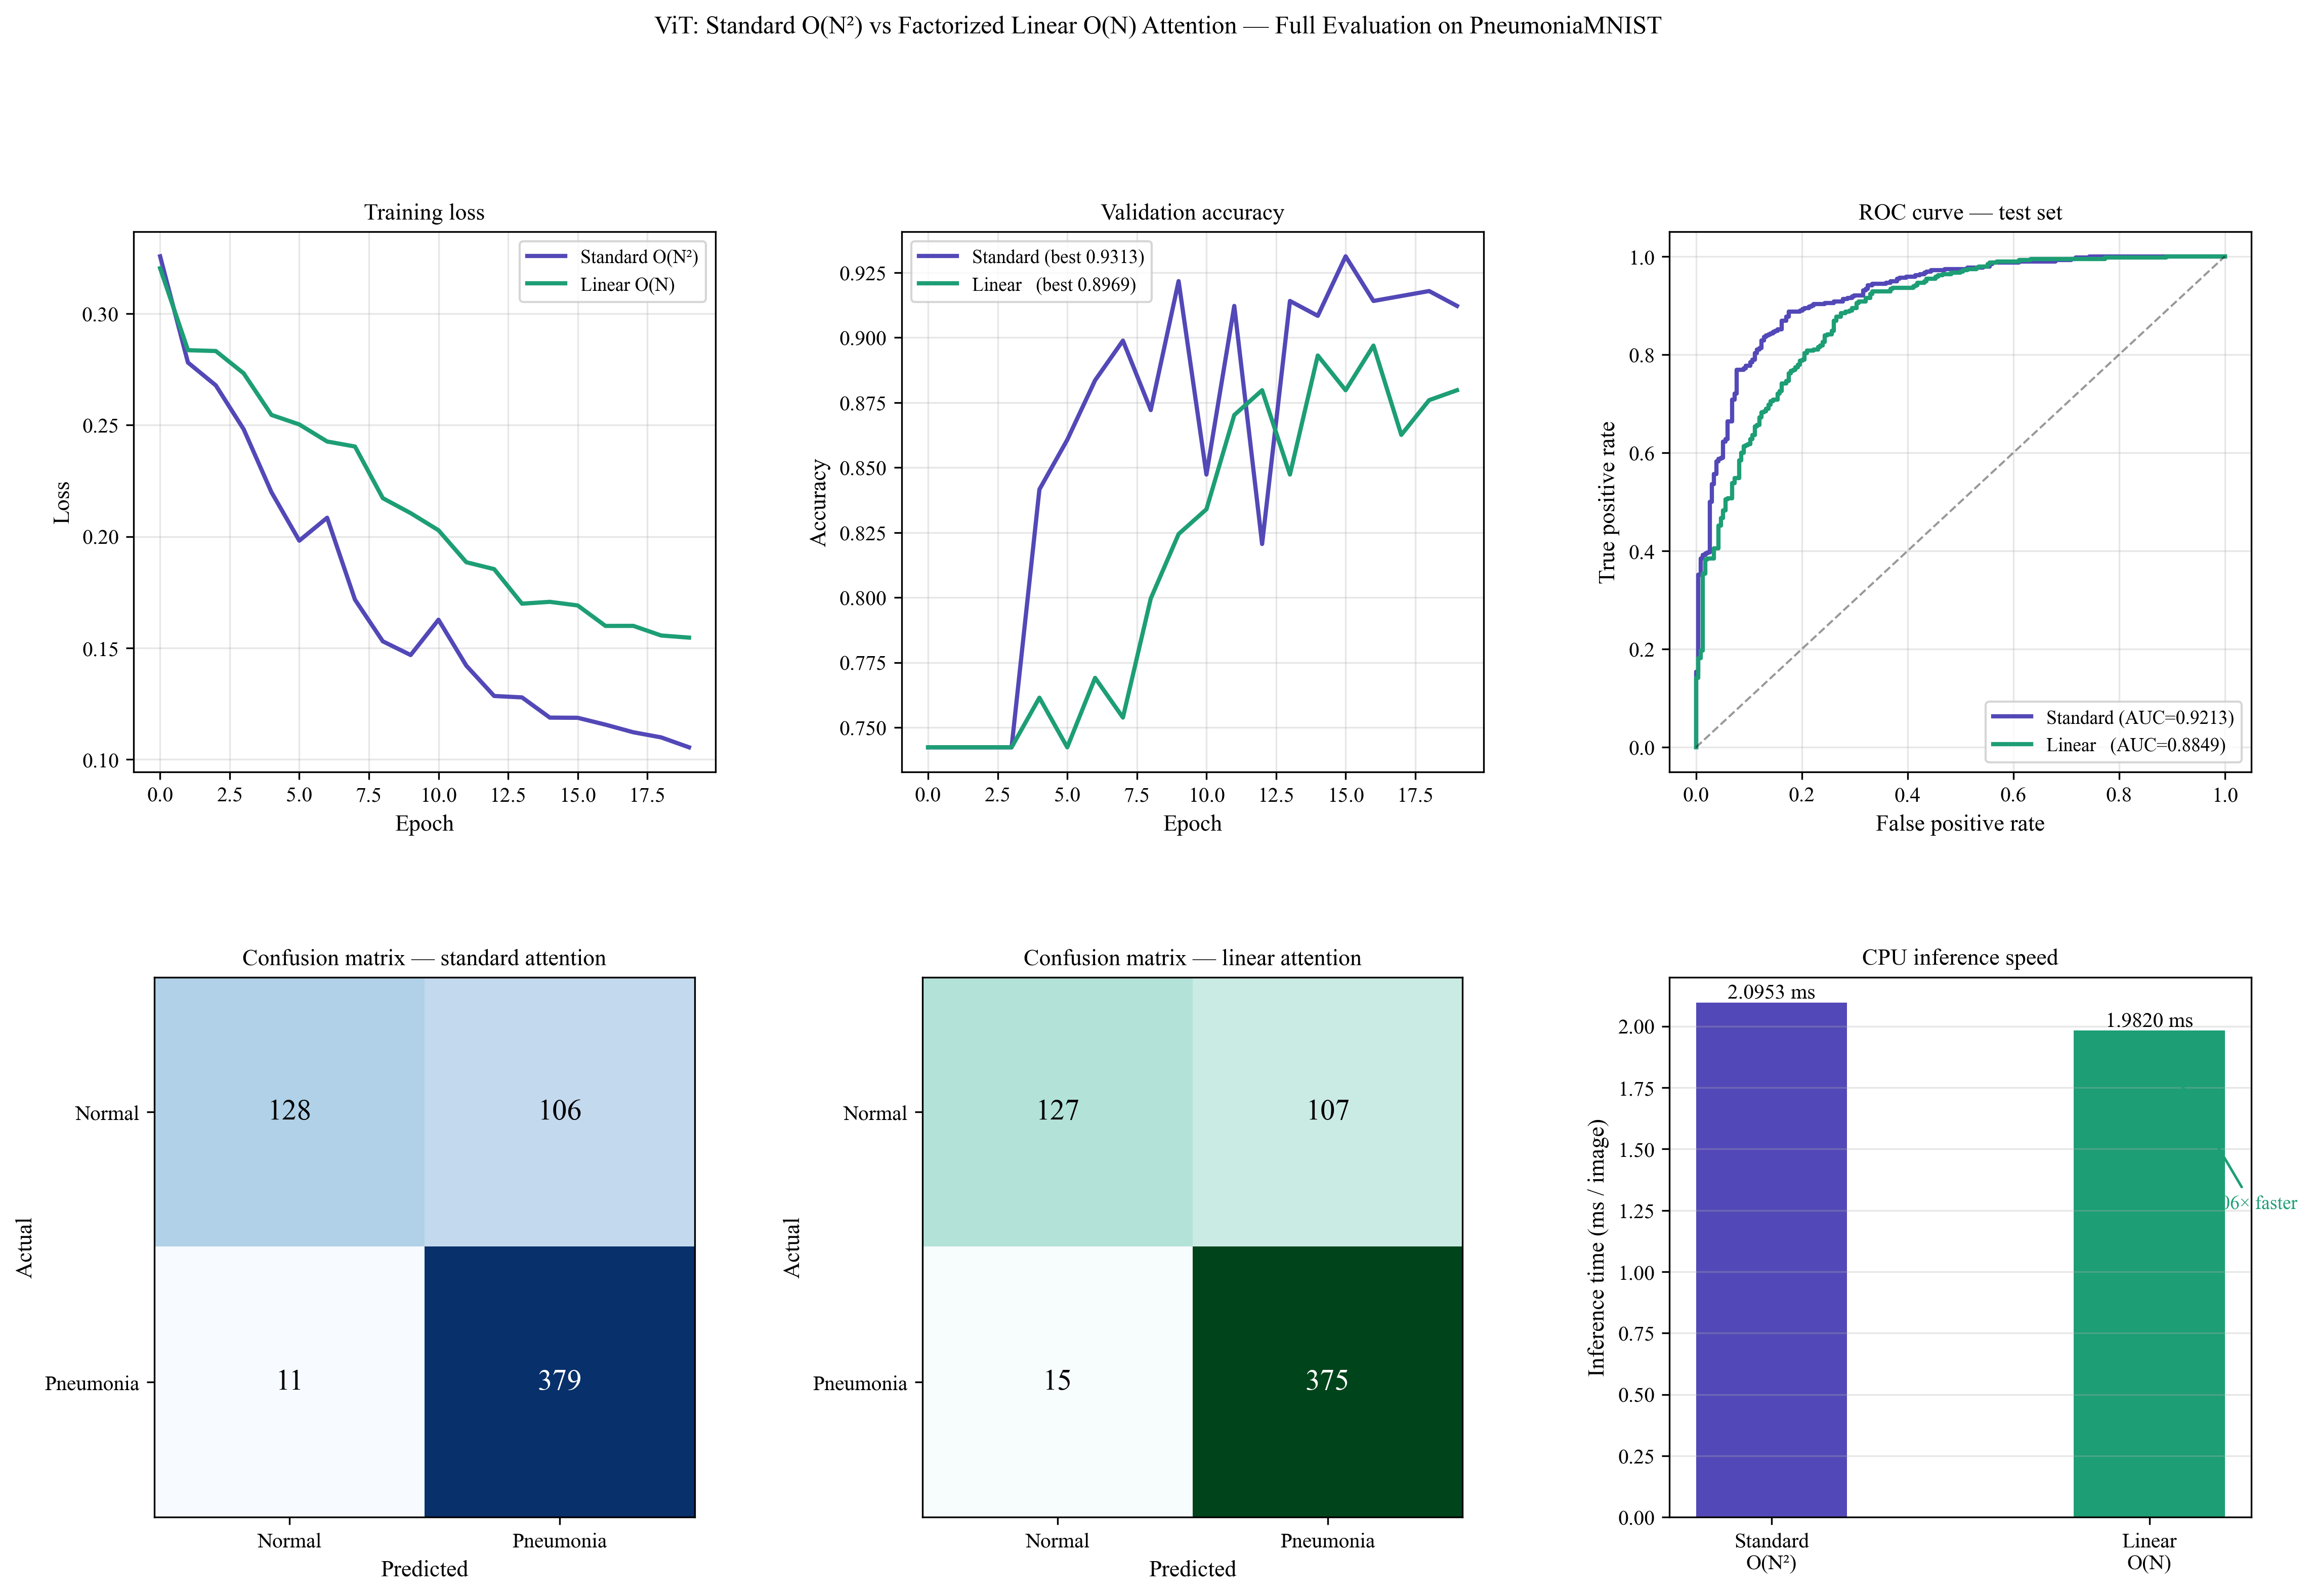


Saved evaluation_results.png

  Metric                      Standard     Linear
  Best val accuracy             0.9313     0.8969
  Test ROC-AUC                  0.9213     0.8849
  Inference (ms/img)            2.0953     1.9820
  Parameters                   556,322    556,322
  Attention complexity           O(N²)       O(N)


In [11]:
import matplotlib
matplotlib.rcParams['font.family']      = 'Times New Roman'
matplotlib.rcParams['font.size']        = 11
matplotlib.rcParams['axes.titlesize']   = 12
matplotlib.rcParams['axes.labelsize']   = 11
matplotlib.rcParams['xtick.labelsize']  = 10
matplotlib.rcParams['ytick.labelsize']  = 10
matplotlib.rcParams['legend.fontsize']  = 9
matplotlib.rcParams['figure.dpi']       = 300

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json, time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from einops import rearrange, repeat
from torchvision import transforms
from PIL import Image

# ── Reload test loader ───────────────────────────────────────────────────

data = np.load('PneumoniaMNIST/pneumoniamnist.npz')

transform_eval = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

class PneumoniaDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels.squeeze().astype(np.int64)
        self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img   = Image.fromarray(self.images[idx])
        img   = self.transform(img) if self.transform else transforms.ToTensor()(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

test_ds     = PneumoniaDataset(data['test_images'], data['test_labels'], transform_eval)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

# ── Evaluate one model ───────────────────────────────────────────────────

def evaluate(attn_type):
    model = ViT(attn_type=attn_type)
    model.load_state_dict(torch.load(f'checkpoints/best_{attn_type}.pt',
                                     map_location='cpu'))
    model.eval()

    all_preds, all_probs, all_labels = [], [], []

    # Measure inference time over full test set
    t0 = time.time()
    with torch.no_grad():
        for imgs, labels in test_loader:
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.numpy())
            all_probs.extend(probs.numpy())
            all_labels.extend(labels.numpy())
    inf_ms = (time.time() - t0) / len(test_ds) * 1000  # ms per image

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    auc = roc_auc_score(all_labels, all_probs)
    cm  = confusion_matrix(all_labels, all_preds)

    print(f"\n{'='*55}")
    print(f"  {attn_type.upper()} ATTENTION — Test Set Results")
    print(f"{'='*55}")
    print(f"  AUC              : {auc:.4f}")
    print(f"  Inference time   : {inf_ms:.4f} ms / image")
    print(classification_report(all_labels, all_preds,
                                target_names=['Normal', 'Pneumonia'], digits=4))

    return all_labels, all_preds, all_probs, auc, cm, inf_ms


std_labels, std_preds, std_probs, std_auc, std_cm, std_ms = evaluate('standard')
lin_labels, lin_preds, lin_probs, lin_auc, lin_cm, lin_ms = evaluate('linear')

# ── Load training histories ──────────────────────────────────────────────

std_hist = json.load(open('checkpoints/history_standard.json'))
lin_hist = json.load(open('checkpoints/history_linear.json'))

# ── Plot all results ─────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

PURPLE = '#5348B7'
TEAL   = '#1D9E75'

# 1. Training loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(std_hist['train_loss'], color=PURPLE, lw=2, label='Standard O(N²)')
ax1.plot(lin_hist['train_loss'], color=TEAL,   lw=2, label='Linear O(N)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training loss', fontsize=11, fontweight='medium')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# 2. Validation accuracy curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(std_hist['val_acc'], color=PURPLE, lw=2, label=f'Standard (best {max(std_hist["val_acc"]):.4f})')
ax2.plot(lin_hist['val_acc'], color=TEAL,   lw=2, label=f'Linear   (best {max(lin_hist["val_acc"]):.4f})')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation accuracy', fontsize=11, fontweight='medium')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# 3. ROC curves
ax3 = fig.add_subplot(gs[0, 2])
for probs, labels, auc, name, col in [
    (std_probs, std_labels, std_auc, f'Standard (AUC={std_auc:.4f})', PURPLE),
    (lin_probs, lin_labels, lin_auc, f'Linear   (AUC={lin_auc:.4f})', TEAL),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    ax3.plot(fpr, tpr, color=col, lw=2, label=name)
ax3.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4)
ax3.set_xlabel('False positive rate'); ax3.set_ylabel('True positive rate')
ax3.set_title('ROC curve — test set', fontsize=11, fontweight='medium')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# 4. Confusion matrix — standard
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.imshow(std_cm, cmap='Blues')
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels(['Normal','Pneumonia'])
ax4.set_yticklabels(['Normal','Pneumonia'])
for i in range(2):
    for j in range(2):
        ax4.text(j, i, std_cm[i,j], ha='center', va='center', fontsize=14,
                 color='white' if std_cm[i,j] > std_cm.max()*0.6 else 'black')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('Actual')
ax4.set_title('Confusion matrix — standard attention', fontsize=11, fontweight='medium')

# 5. Confusion matrix — linear
ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.imshow(lin_cm, cmap='BuGn')
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(['Normal','Pneumonia'])
ax5.set_yticklabels(['Normal','Pneumonia'])
for i in range(2):
    for j in range(2):
        ax5.text(j, i, lin_cm[i,j], ha='center', va='center', fontsize=14,
                 color='white' if lin_cm[i,j] > lin_cm.max()*0.6 else 'black')
ax5.set_xlabel('Predicted'); ax5.set_ylabel('Actual')
ax5.set_title('Confusion matrix — linear attention', fontsize=11, fontweight='medium')

# 6. Inference speed bar chart
ax6 = fig.add_subplot(gs[1, 2])
bars = ax6.bar(
    ['Standard\nO(N²)', 'Linear\nO(N)'],
    [std_ms, lin_ms],
    color=[PURPLE, TEAL],
    width=0.4, edgecolor='none'
)
for bar, val in zip(bars, [std_ms, lin_ms]):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0002,
             f'{val:.4f} ms', ha='center', va='bottom', fontsize=10)
ax6.set_ylabel('Inference time (ms / image)')
ax6.set_title('CPU inference speed', fontsize=11, fontweight='medium')
ax6.grid(axis='y', alpha=0.3)
# Annotate speedup
speedup = std_ms / lin_ms
ax6.annotate(f'{speedup:.2f}× faster' if lin_ms < std_ms else f'{1/speedup:.2f}× slower',
             xy=(1, lin_ms), xytext=(1.15, max(std_ms, lin_ms)*0.6),
             fontsize=9, color=TEAL,
             arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.2))

fig.suptitle(
    'ViT: Standard O(N²) vs Factorized Linear O(N) Attention — Full Evaluation on PneumoniaMNIST',
    fontsize=12, fontweight='medium', y=1.01
)

plt.savefig('evaluation_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved evaluation_results.png")

# ── Summary table ────────────────────────────────────────────────────────

print("\n" + "="*55)
print(f"  {'Metric':<25} {'Standard':>10} {'Linear':>10}")
print("="*55)
print(f"  {'Best val accuracy':<25} {max(std_hist['val_acc']):>10.4f} {max(lin_hist['val_acc']):>10.4f}")
print(f"  {'Test ROC-AUC':<25} {std_auc:>10.4f} {lin_auc:>10.4f}")
print(f"  {'Inference (ms/img)':<25} {std_ms:>10.4f} {lin_ms:>10.4f}")
print(f"  {'Parameters':<25} {'556,322':>10} {'556,322':>10}")
print(f"  {'Attention complexity':<25} {'O(N²)':>10} {'O(N)':>10}")
print("="*55)

C:\Users\SUBHADEEP SASMAL\AppData\Local\Temp\ipykernel_20188\3573615160.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'checkpoints/b

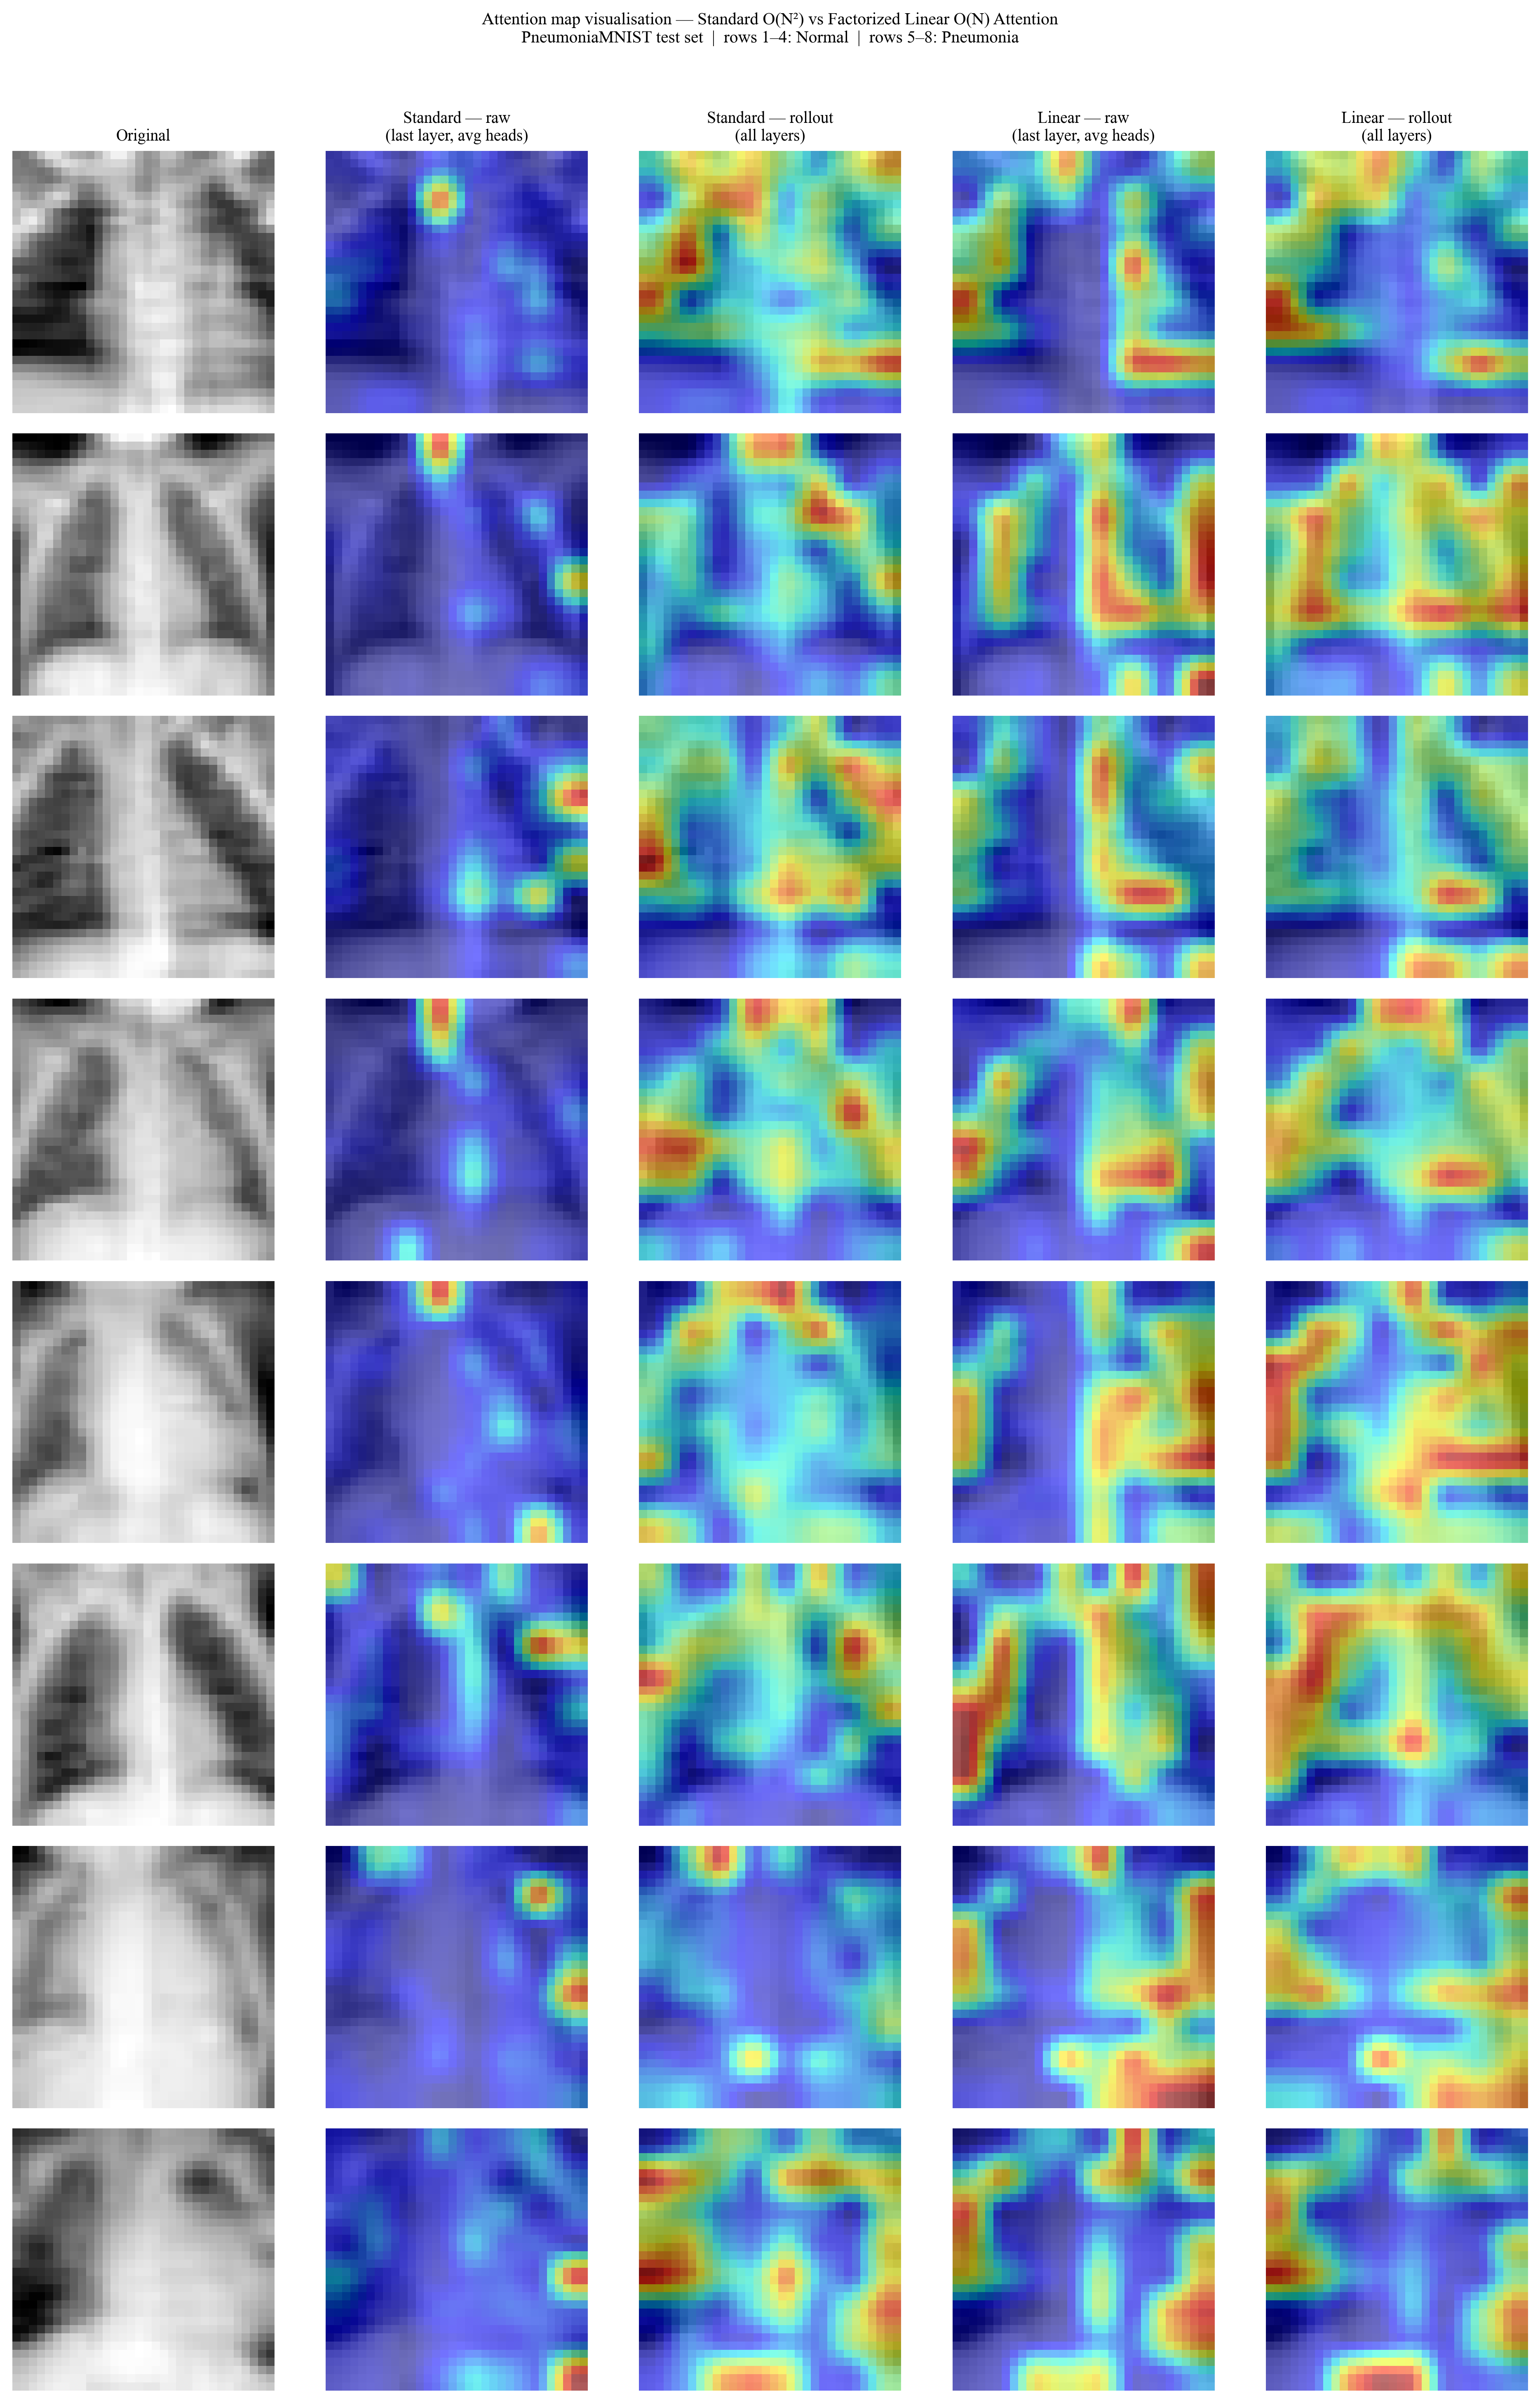

Saved attention_maps.png


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from einops import rearrange, repeat

matplotlib.rcParams['font.family']     = 'Times New Roman'
matplotlib.rcParams['font.size']       = 11
matplotlib.rcParams['axes.titlesize']  = 11
matplotlib.rcParams['axes.labelsize']  = 10
matplotlib.rcParams['figure.dpi']      = 300

# ── Attention rollout (Abnar & Zuidema, 2020) ────────────────────────────
# Intuition: attention flows through every layer via residual connections.
# Rollout multiplies all layer attention matrices together to get the
# true information flow from the CLS token to every patch.

def attention_rollout(attn_list):
    """
    attn_list : list of tensors, each shape (1, heads, N+1, N+1)
    returns   : numpy array of shape (num_patches,) — one score per patch
    """
    rollout = None
    for attn in attn_list:
        # Average across heads → (1, N+1, N+1)
        attn_mean = attn.mean(dim=1)
        # Add identity (residual connection) and re-normalise
        attn_mean = attn_mean + torch.eye(attn_mean.size(-1))
        attn_mean = attn_mean / attn_mean.sum(dim=-1, keepdim=True)

        if rollout is None:
            rollout = attn_mean
        else:
            rollout = torch.bmm(attn_mean, rollout)

    # CLS token row (index 0) → attention from CLS to every patch
    # Skip index 0 (CLS-to-CLS), keep patch tokens [1:]
    cls_attn = rollout[0, 0, 1:].detach().cpu().numpy()
    return cls_attn


def raw_last_layer_attn(attn_list):
    """
    Average attention from CLS token across heads in the final layer only.
    Simpler than rollout but ignores earlier layers.
    """
    last = attn_list[-1]                      # (1, heads, N+1, N+1)
    cls  = last.mean(dim=1)[0, 0, 1:]         # (num_patches,)
    return cls.detach().cpu().numpy()


def attn_to_heatmap(attn_scores, grid_size=8):
    """Reshape flat patch scores to (grid_size, grid_size) and normalise."""
    heatmap = attn_scores.reshape(grid_size, grid_size)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap


def overlay_heatmap(ax, original_img, heatmap, alpha=0.55, cmap='jet'):
    """Overlay a heatmap on the original image."""
    h, w = original_img.shape[:2]
    heatmap_resized = np.array(
        Image.fromarray((heatmap * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR)
    ) / 255.0
    ax.imshow(original_img, cmap='gray')
    ax.imshow(heatmap_resized, cmap=cmap, alpha=alpha, vmin=0, vmax=1)
    ax.axis('off')


# ── Load both models with attention weight hooks ─────────────────────────

def load_model(attn_type):
    model = ViT(attn_type=attn_type)
    model.load_state_dict(torch.load(f'checkpoints/best_{attn_type}.pt',
                                     map_location='cpu'))
    model.eval()
    return model

std_model = load_model('standard')
lin_model = load_model('linear')

# ── Select images: 4 Normal, 4 Pneumonia from test set ───────────────────

data           = np.load('PneumoniaMNIST/pneumoniamnist.npz')
test_images    = data['test_images']
test_labels    = data['test_labels'].squeeze()

normal_idx    = np.where(test_labels == 0)[0][:4]
pneumonia_idx = np.where(test_labels == 1)[0][:4]
selected_idx  = np.concatenate([normal_idx, pneumonia_idx])   # 8 images total

transform_eval = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

def preprocess(img_np):
    """uint8 (28,28) → normalised tensor (1,1,32,32)"""
    pil = Image.fromarray(img_np)
    t   = transform_eval(pil).unsqueeze(0)   # (1,1,32,32)
    return t

def get_display_img(img_np):
    """uint8 → resized (32,32) float for display"""
    return np.array(Image.fromarray(img_np).resize((32,32), Image.BILINEAR))


# ── Build figure ─────────────────────────────────────────────────────────
# Layout per image: original | std raw | std rollout | lin raw | lin rollout
# 8 images × 5 columns

n_images = len(selected_idx)
fig, axes = plt.subplots(n_images, 5, figsize=(13, 2.4 * n_images))

col_titles = [
    'Original',
    'Standard — raw\n(last layer, avg heads)',
    'Standard — rollout\n(all layers)',
    'Linear — raw\n(last layer, avg heads)',
    'Linear — rollout\n(all layers)',
]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9.5, pad=6)

for row, idx in enumerate(selected_idx):
    img_np    = test_images[idx]
    label_str = 'Pneumonia' if test_labels[idx] == 1 else 'Normal'
    tensor    = preprocess(img_np)
    disp_img  = get_display_img(img_np)

    results = {}
    for name, model in [('std', std_model), ('lin', lin_model)]:
        with torch.no_grad():
            _ = model(tensor)
        attn_list = model.get_attention_maps()   # list of (1, H, N+1, N+1)

        results[name] = {
            'raw'     : attn_to_heatmap(raw_last_layer_attn(attn_list)),
            'rollout' : attn_to_heatmap(attention_rollout(attn_list)),
        }

    # Col 0: original
    axes[row, 0].imshow(disp_img, cmap='gray')
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(label_str, fontsize=9, rotation=0,
                             labelpad=48, va='center')

    # Col 1: standard raw
    overlay_heatmap(axes[row, 1], disp_img, results['std']['raw'])
    # Col 2: standard rollout
    overlay_heatmap(axes[row, 2], disp_img, results['std']['rollout'])
    # Col 3: linear raw
    overlay_heatmap(axes[row, 3], disp_img, results['lin']['raw'])
    # Col 4: linear rollout
    overlay_heatmap(axes[row, 4], disp_img, results['lin']['rollout'])

fig.suptitle(
    'Attention map visualisation — Standard O(N²) vs Factorized Linear O(N) Attention\n'
    'PneumoniaMNIST test set  |  rows 1–4: Normal  |  rows 5–8: Pneumonia',
    fontsize=10, y=1.01
)

plt.tight_layout()
plt.savefig('attention_maps.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved attention_maps.png")

Total configurations to train: 23  (10 epochs each)

▶  Depth (num layers)
  [1/23]  depth=2 ... val_acc=0.8779  auc=0.9365  params=292,130  time=126.5s
  [2/23]  baseline ... val_acc=0.8779  auc=0.9449  params=556,322  time=201.5s
  [3/23]  depth=6 ... val_acc=0.8969  auc=0.9435  params=820,514  time=290.5s
  [4/23]  depth=8 ... val_acc=0.8969  auc=0.9509  params=1,084,706  time=371.4s

▶  Heads (attention heads)
  [5/23]  heads=1 ... val_acc=0.8683  auc=0.9306  params=556,322  time=163.3s
  [6/23]  heads=2 ... val_acc=0.8740  auc=0.9429  params=556,322  time=205.4s
  [7/23]  baseline ... val_acc=0.8874  auc=0.9464  params=556,322  time=206.5s
  [8/23]  heads=8 ... val_acc=0.9008  auc=0.9581  params=556,322  time=219.9s

▶  Patch size
  [9/23]  patch_size=2 ... val_acc=0.9179  auc=0.9619  params=579,338  time=994.6s
  [10/23]  baseline ... val_acc=0.9084  auc=0.9467  params=556,322  time=192.3s
  [11/23]  patch_size=8 ... val_acc=0.9275  auc=0.9702  params=556,418  time=73.1s

▶  Embe

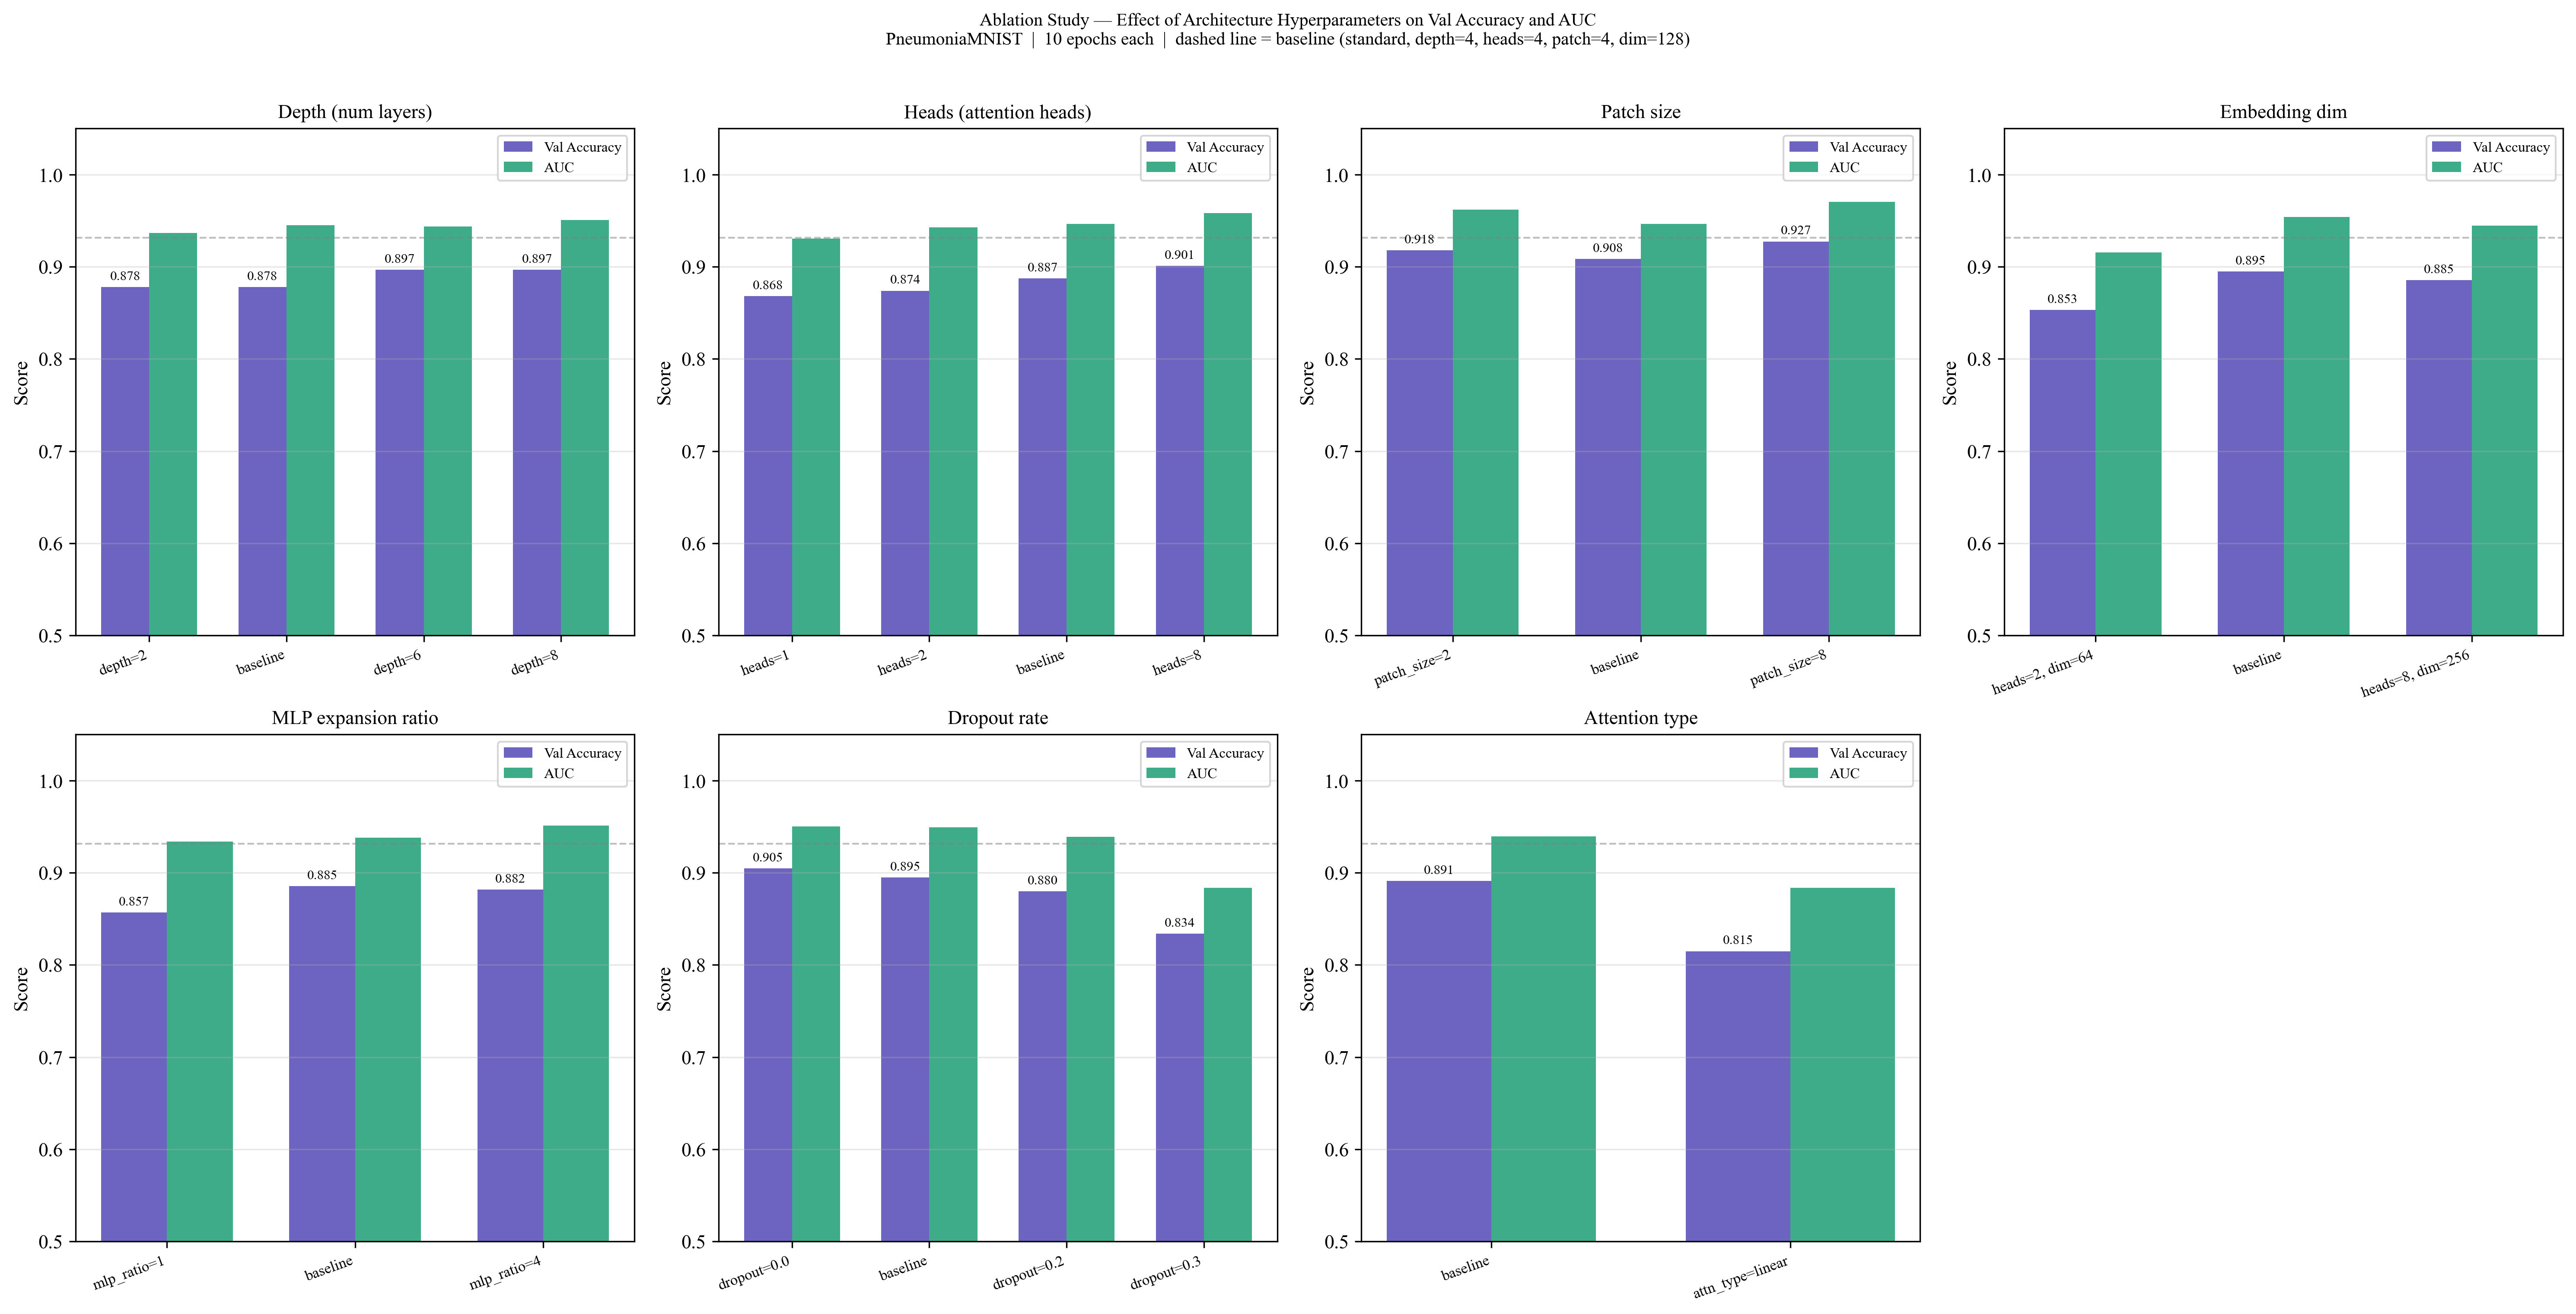

Saved ablation_results.png

  Group                      Config                  Val Acc      AUC     Params
  Depth (num layers)         depth=2                  0.8779   0.9365    292,130
  Depth (num layers)         baseline                 0.8779   0.9449    556,322
  Depth (num layers)         depth=6                  0.8969   0.9435    820,514
  Depth (num layers)         depth=8                  0.8969   0.9509  1,084,706
  Heads (attention heads)    heads=1                  0.8683   0.9306    556,322
  Heads (attention heads)    heads=2                  0.8740   0.9429    556,322
  Heads (attention heads)    baseline                 0.8874   0.9464    556,322
  Heads (attention heads)    heads=8                  0.9008   0.9581    556,322
  Patch size                 patch_size=2             0.9179   0.9619    579,338
  Patch size                 baseline                 0.9084   0.9467    556,322
  Patch size                 patch_size=8             0.9275   0.9702    556,418


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json, time, os, itertools
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from PIL import Image
from einops import rearrange, repeat
from copy import deepcopy

matplotlib.rcParams['font.family']    = 'Times New Roman'
matplotlib.rcParams['font.size']      = 11
matplotlib.rcParams['axes.titlesize'] = 12
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['figure.dpi']    = 300

# ── Dataset ──────────────────────────────────────────────────────────────

data = np.load('PneumoniaMNIST/pneumoniamnist.npz')

class PneumoniaDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels.squeeze().astype(np.int64)
        self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img   = Image.fromarray(self.images[idx])
        img   = self.transform(img) if self.transform else transforms.ToTensor()(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

def get_loaders(img_size=32, batch_size=64):
    tr = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])
    ev = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])
    train_loader = DataLoader(PneumoniaDataset(data['train_images'], data['train_labels'], tr),
                              batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(PneumoniaDataset(data['val_images'],   data['val_labels'],   ev),
                              batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader

# ── Model ─────────────────────────────────────────────────────────────────

def phi(x): return F.elu(x) + 1

class StandardAttention(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        self.heads    = heads
        self.head_dim = dim // heads
        self.scale    = self.head_dim ** -0.5
        self.qkv      = nn.Linear(dim, dim * 3, bias=False)
        self.proj     = nn.Linear(dim, dim)
        self.drop     = nn.Dropout(dropout)
        self.attn_weights = None
    def forward(self, x):
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.heads)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.heads)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.heads)
        attn = (torch.einsum('bhid,bhjd->bhij', q, k) * self.scale).softmax(dim=-1)
        self.attn_weights = attn.detach()
        out = torch.einsum('bhij,bhjd->bhid', self.drop(attn), v)
        return self.proj(rearrange(out, 'b h n d -> b n (h d)'))

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        self.heads    = heads
        self.head_dim = dim // heads
        self.qkv      = nn.Linear(dim, dim * 3, bias=False)
        self.proj     = nn.Linear(dim, dim)
        self.drop     = nn.Dropout(dropout)
        self.attn_weights = None
    def forward(self, x):
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.heads)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.heads)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.heads)
        q, k  = phi(q), phi(k)
        kv    = torch.einsum('bhnd,bhnm->bhdm', k, v)
        out   = torch.einsum('bhnd,bhdm->bhnm', q, kv)
        denom = torch.einsum('bhnd,bhd->bhn', q, k.sum(dim=2)).unsqueeze(-1).clamp(min=1e-6)
        out   = out / denom
        with torch.no_grad():
            a = torch.einsum('bhnd,bhmd->bhnm', q, k)
            self.attn_weights = (a / a.sum(dim=-1, keepdim=True).clamp(min=1e-6)).detach()
        return self.proj(rearrange(out, 'b h n d -> b n (h d)'))

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_dim, attn_cls, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = attn_cls(dim, heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

class ViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, num_classes=2,
                 dim=128, depth=4, heads=4, mlp_dim=256,
                 attn_type='standard', dropout=0.1):
        super().__init__()
        assert image_size % patch_size == 0, \
            f"image_size {image_size} not divisible by patch_size {patch_size}"
        assert dim % heads == 0, \
            f"dim {dim} not divisible by heads {heads}"
        num_patches      = (image_size // patch_size) ** 2
        patch_dim        = patch_size * patch_size
        self.patch_size  = patch_size
        self.patch_embed = nn.Sequential(
            nn.LayerNorm(patch_dim), nn.Linear(patch_dim, dim), nn.LayerNorm(dim),
        )
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim) * 0.02)
        self.dropout   = nn.Dropout(dropout)
        attn_cls       = LinearAttention if attn_type == 'linear' else StandardAttention
        self.blocks    = nn.ModuleList([
            Block(dim, heads, mlp_dim, attn_cls, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(
            nn.Linear(dim, mlp_dim // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(mlp_dim // 2, num_classes),
        )
    def forward(self, img):
        p = self.patch_size
        x = rearrange(img, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=p, p2=p)
        x = self.patch_embed(x)
        B = x.shape[0]
        x = torch.cat([repeat(self.cls_token, '1 1 d -> b 1 d', b=B), x], dim=1) + self.pos_embed
        x = self.dropout(x)
        for block in self.blocks: x = block(x)
        return self.head(self.norm(x[:, 0]))
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# ── Single training run ───────────────────────────────────────────────────

def run_single(config, epochs=10):
    """
    config : dict with keys — attn_type, depth, heads, patch_size, dim,
                               mlp_ratio, dropout
    Returns : dict with val_acc, auc, params, train_time
    """
    mlp_dim = int(config['dim'] * config['mlp_ratio'])

    # Guard: mlp_dim // 2 must be > 0
    if mlp_dim < 2:
        return None

    img_size = 32
    try:
        model = ViT(
            image_size  = img_size,
            patch_size  = config['patch_size'],
            dim         = config['dim'],
            depth       = config['depth'],
            heads       = config['heads'],
            mlp_dim     = mlp_dim,
            attn_type   = config['attn_type'],
            dropout     = config['dropout'],
        )
    except AssertionError as e:
        print(f"  Skipped (invalid config): {e}")
        return None

    train_loader, val_loader = get_loaders(img_size=img_size)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

    # Evaluate on val set
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            all_preds.extend(logits.argmax(dim=1).numpy())
            all_probs.extend(probs.numpy())
            all_labels.extend(labels.numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    val_acc    = (all_preds == all_labels).mean()
    auc        = roc_auc_score(all_labels, np.array(all_probs))
    train_time = time.time() - t0

    return {
        'val_acc'    : round(val_acc, 4),
        'auc'        : round(auc, 4),
        'params'     : model.count_parameters(),
        'train_time' : round(train_time, 1),
    }

# ── Ablation definitions ──────────────────────────────────────────────────
# Baseline config — matches your fully trained model
BASELINE = {
    'attn_type'  : 'standard',
    'depth'      : 4,
    'heads'      : 4,
    'patch_size' : 4,
    'dim'        : 128,
    'mlp_ratio'  : 2,       # mlp_dim = dim × mlp_ratio = 256
    'dropout'    : 0.1,
}

ablation_groups = {
    'Depth (num layers)'      : [dict(BASELINE, depth=v)      for v in [2, 4, 6, 8]],
    'Heads (attention heads)' : [dict(BASELINE, heads=v)      for v in [1, 2, 4, 8]],
    'Patch size'              : [dict(BASELINE, patch_size=v) for v in [2, 4, 8]],
    'Embedding dim'           : [dict(BASELINE, dim=v,
                                       heads=min(v//32, 8) if v >= 64 else 1)
                                  for v in [64, 128, 256]],
    'MLP expansion ratio'     : [dict(BASELINE, mlp_ratio=v)  for v in [1, 2, 4]],
    'Dropout rate'            : [dict(BASELINE, dropout=v)    for v in [0.0, 0.1, 0.2, 0.3]],
    'Attention type'          : [dict(BASELINE, attn_type=v)  for v in ['standard', 'linear']],
}

# ── Run all ablations ─────────────────────────────────────────────────────

os.makedirs('checkpoints', exist_ok=True)
all_results = {}
total_runs  = sum(len(v) for v in ablation_groups.values())
run_idx     = 0

print(f"Total configurations to train: {total_runs}  (10 epochs each)")
print("="*65)

for group_name, configs in ablation_groups.items():
    group_results = []
    print(f"\n▶  {group_name}")
    for cfg in configs:
        run_idx += 1
        # Build a short label for this config
        changed = {k: cfg[k] for k in cfg if cfg[k] != BASELINE.get(k)}
        label   = ', '.join(f"{k}={v}" for k, v in changed.items()) or 'baseline'
        print(f"  [{run_idx}/{total_runs}]  {label} ... ", end='', flush=True)

        result = run_single(cfg, epochs=10)
        if result is None:
            print("skipped")
            continue

        result['label']  = label
        result['config'] = cfg
        group_results.append(result)
        print(f"val_acc={result['val_acc']:.4f}  auc={result['auc']:.4f}  "
              f"params={result['params']:,}  time={result['train_time']}s")

    all_results[group_name] = group_results

# Save results
with open('checkpoints/ablation_results.json', 'w') as f:
    # configs contain non-serialisable entries — save only metrics
    serialisable = {
        g: [{'label': r['label'], 'val_acc': r['val_acc'],
             'auc': r['auc'], 'params': r['params']} for r in res]
        for g, res in all_results.items()
    }
    json.dump(serialisable, f, indent=2)

print("\n\nAll runs complete. Results saved to checkpoints/ablation_results.json")

# ── Plot ablation results ─────────────────────────────────────────────────

n_groups = len(all_results)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flat

PURPLE = '#5348B7'
TEAL   = '#1D9E75'
COLORS = ['#5348B7', '#1D9E75', '#D85A30', '#BA7517',
          '#185FA5', '#3B6D11', '#993556', '#888780']

for ax_idx, (group_name, results) in enumerate(all_results.items()):
    ax     = axes[ax_idx]
    labels = [r['label'] for r in results]
    accs   = [r['val_acc'] for r in results]
    aucs   = [r['auc']     for r in results]

    x    = np.arange(len(labels))
    w    = 0.35
    bars = ax.bar(x - w/2, accs, w, label='Val Accuracy',
                  color=PURPLE, alpha=0.85, edgecolor='none')
    ax.bar(x + w/2, aucs, w, label='AUC',
           color=TEAL, alpha=0.85, edgecolor='none')

    # Annotate bars
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8.5)
    ax.set_ylim(0.5, 1.05)
    ax.set_title(group_name, fontsize=11)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.9313, color='gray', lw=1, ls='--', alpha=0.5,
               label='Baseline (0.9313)')

# Hide unused subplots
for i in range(len(all_results), len(list(axes))):
    axes[i].set_visible(False)

fig.suptitle(
    'Ablation Study — Effect of Architecture Hyperparameters on Val Accuracy and AUC\n'
    'PneumoniaMNIST  |  10 epochs each  |  dashed line = baseline (standard, depth=4, '
    'heads=4, patch=4, dim=128)',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.savefig('ablation_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved ablation_results.png")

# ── Print clean summary table ─────────────────────────────────────────────

print("\n" + "="*65)
print(f"  {'Group':<26} {'Config':<22} {'Val Acc':>8} {'AUC':>8} {'Params':>10}")
print("="*65)
for group_name, results in all_results.items():
    for r in results:
        print(f"  {group_name:<26} {r['label']:<22} "
              f"{r['val_acc']:>8.4f} {r['auc']:>8.4f} {r['params']:>10,}")
print("="*65)